In [43]:
# Cell 1A: Imports and Basic Helper Functions
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.patches import Rectangle
import os # For creating directories

def parse_line_kv_only(line: str):
    """Parses a comma-separated key-value string line into a dictionary."""
    result = {}
    for kv in line.split(","):
        if "=" in kv: k, v = kv.split("="); result[k] = v
    return result

def aggregate_dicts(dicts: list[dict]):
    """Aggregates a list of dictionaries based on a composite key."""
    aggregated = defaultdict(lambda: defaultdict(list))
    for d_item in dicts:
        key = (d_item.get("param"), d_item.get("noise_level"), d_item.get("n_pts"), d_item.get("n_indivs"))
        for k, v in d_item.items():
            if k not in {"param", "noise_level", "n_pts", "n_indivs"}: aggregated[key][k].append(v)
    return dict(aggregated)

def aggregate(param_char):
    """Loads data from a file and aggregates it."""
    filename = f"results_{param_char.replace('\'','')}_v2.txt"
    try:
        with open(filename, "r") as f:
            lines = [line.strip() for line in f.readlines()]
            results = [parse_line_kv_only(line) for line in lines]
            agg = aggregate_dicts(results)
        return agg
    except FileNotFoundError:
        print(f"Warning: Data file {filename} not found for parameter {param_char}.")
        return None

def get_cmap_bounds(params, include_NR=True):
    """Computes min/max of medians for specific keys for a list of parameters."""
    keys_to_check = []
    base_metrics = ["param_relative_err", "rms_log_T", "rms_log_C"]
    outcomes = ["CR"]
    if include_NR: outcomes.append("NR")
    for bm in base_metrics:
        for oc in outcomes: keys_to_check.append(f"{bm}_{oc}")
    if "param_relative_err" not in keys_to_check: keys_to_check.append("param_relative_err")

    bounds = {key: [float("inf"), float("-inf")] for key in keys_to_check}
    for param_char in params: 
        agg_data = aggregate(param_char) 
        if agg_data is None: continue
        for ddk_tuple in agg_data: 
            for mk in keys_to_check:
                if mk in agg_data[ddk_tuple]:
                    vf_vals = []
                    for x_str in agg_data[ddk_tuple][mk]:
                        try: 
                            v_f = float(x_str)
                            if not np.isnan(v_f): vf_vals.append(v_f)
                        except (ValueError, TypeError): pass 
                    if vf_vals: 
                        med_val = np.median(vf_vals)
                        if not np.isnan(med_val): 
                            bounds[mk][0] = min(bounds[mk][0], med_val); bounds[mk][1] = max(bounds[mk][1], med_val)
    final_b = {}
    for kb in keys_to_check:
        min_v, max_v = bounds[kb]
        final_b[kb] = (None, None) if min_v == float("inf") or max_v == float("-inf") else (min_v, max_v)
    return final_b

In [44]:
# Cell 1B: Core Heatmap Drawing Utilities

def enhanced_plot_heatmap(heatmap, x_labels, y_labels, title, 
                          log_scale=True, cmap='viridis',
                          vmin=None, vmax=None, highlight_thresh=None, save_fname=None):
    # Kept as per original code structure, not primary for Cell 3/4 combined plots
    fig, ax = plt.subplots(figsize=(10, 6)); fig.patch.set_facecolor('white')
    hm_arr = np.array(heatmap)
    eff_vmin_log = vmin if not (log_scale and vmin is not None and vmin <= 0) else None
    log_vmin_def, log_vmax_def = 1e-1, 1.0
    if np.any(hm_arr[np.nonzero(hm_arr)]):
        valid_data_for_log = hm_arr[hm_arr > 0]
        if valid_data_for_log.size > 0:
            log_vmin_def, log_vmax_def = np.nanmin(valid_data_for_log), np.nanmax(valid_data_for_log)
            if log_vmin_def >= log_vmax_def: log_vmax_def = log_vmin_def * 10 if log_vmin_def > 0 else 1.0
    
    norm_vmin_def, norm_vmax_def = 0.0, 1.0
    if not np.all(np.isnan(hm_arr)): 
        temp_min, temp_max = np.nanmin(hm_arr), np.nanmax(hm_arr)
        if not (np.isnan(temp_min) or np.isnan(temp_max)):
             norm_vmin_def, norm_vmax_def = temp_min, temp_max
             if norm_vmin_def >= norm_vmax_def: norm_vmax_def = norm_vmin_def + 1.0

    norm = LogNorm(vmin=eff_vmin_log or log_vmin_def, vmax=vmax or log_vmax_def) if log_scale \
           else Normalize(vmin=vmin or norm_vmin_def, vmax=vmax or norm_vmax_def)

    cax_img = ax.imshow(hm_arr, cmap=cmap, aspect='auto', norm=norm)
    ax.add_patch(Rectangle((-0.5,-0.5), hm_arr.shape[1], hm_arr.shape[0], fill=False, ec='black', lw=2))
    for sp in ax.spines.values(): sp.set_edgecolor('black'); sp.set_linewidth(1.5)
    ax.set_xticks(np.arange(len(x_labels))); ax.set_yticks(np.arange(len(y_labels)))
    ax.set_xticklabels(x_labels); ax.set_yticklabels(y_labels)
    ax.set_xlabel("n_pts"); ax.set_ylabel("noise_level"); ax.set_title(title, pad=12, fs=12, weight='bold')
    if highlight_thresh is not None: pass 
    cbar = fig.colorbar(cax_img, ax=ax, pad=0.02); cbar.set_label('Median Value', rotation=270, labelpad=15)
    plt.tight_layout()
    if save_fname: fig.savefig(save_fname, dpi=300, bbox_inches='tight')
    plt.show()


def staircase_boundary(heatmap, threshold):
    """
    Finds the staircase boundary using the user's original vertex generation logic.
    `diff` variable controls spacing from border.
    """
    x_positions = []  # x-coords of boundary per row, from bottom-most row to top-most
    for i in range(heatmap.shape[0] - 1, -1, -1):  # Iterate heatmap rows from bottom-up
        row = heatmap[i, :]
        valid_indices = np.where((~np.isnan(row)) & (row <= threshold))[0]
        if len(valid_indices) > 0:
            j = 1 + valid_indices[-1]
        else:
            j = 0
        x = j - 0.5
        x_positions.append(x)

    # Generate contour vertices USING USER'S ORIGINAL LOGIC provided in the prompt
    if x_positions:
        # x_positions are for rows from bottom to top (index 0 is bottom row).
        # 'i' in this loop also goes from 0 (bottom-most row's x_pos) upwards.
        vertices = [(-0.5, -0.5 + heatmap.shape[0])] # Start top-left of heatmap plot area
        
        # User's original code modified x_positions in place.
        # To avoid altering the original list if it's used elsewhere, work on a copy.
        # However, the original code structure suggests in-place modification was intended here.
        # For safety in a larger context, a copy is good, but to match original behavior:
        # current_x_positions = x_positions # if modification of original is okay
        current_x_positions = list(x_positions) # Safer: work on a copy

        for i_loop_user, x_val_user in enumerate(current_x_positions):
            if i_loop_user > 0 and x_val_user < current_x_positions[i_loop_user - 1]:
                current_x_positions[i_loop_user] = current_x_positions[i_loop_user - 1]
                x_val_user = current_x_positions[i_loop_user]
            
            y_coord_on_plot_user = -0.5 + heatmap.shape[0] - i_loop_user
            
            if (i_loop_user == 0 and x_val_user > 0) or \
               (i_loop_user > 0 and x_val_user > current_x_positions[i_loop_user - 1]):
                vertices.append((x_val_user, y_coord_on_plot_user))
            vertices.append((x_val_user, y_coord_on_plot_user - 1))

        # Check boundary for the top-most row (which is x_positions[-1] or current_x_positions[-1])
        # The y-coordinate for the top edge of the heatmap plot area is -0.5
        if current_x_positions[-1] < (heatmap.shape[1] - 0.5): 
             vertices.append((heatmap.shape[1] - 0.5, -0.5))
        
        diff = 0.035 # Maintained adjusted diff
        # Original code modified 'vertices' list in place during this loop.
        for i_vtx in range(len(vertices)): 
            vx, vy = vertices[i_vtx]
            vx_orig, vy_orig = vx, vy # Store original for checks
            
            if vx_orig == -0.5: vx += diff
            elif vx_orig == heatmap.shape[1] - 0.5: vx -= diff
            
            if vy_orig == -0.5: vy += diff
            elif vy_orig == heatmap.shape[0] - 0.5: vy -= diff
            vertices[i_vtx] = (vx, vy) # Update vertex
        return vertices
    return []


def plot_single_heatmap_on_ax(ax, heatmap_data, x_labels, y_labels, 
                              vertices_T=None, vertices_C=None,
                              log_scale=True, cmap='viridis', vmin=None, vmax=None):
    """Plots a single heatmap. No default Y-label set here."""
    hm_arr = np.array(heatmap_data); eff_vmin = vmin
    if log_scale and vmin is not None and vmin <= 0: eff_vmin = None 
    norm = LogNorm(vmin=eff_vmin, vmax=vmax) if log_scale else Normalize(vmin=vmin, vmax=vmax)
    ax.imshow(hm_arr, cmap=cmap, aspect='auto', norm=norm)
    ax.add_patch(Rectangle((-0.5,-0.5), hm_arr.shape[1],hm_arr.shape[0],fill=False,ec='black',lw=1))
    for sp in ax.spines.values(): sp.set_edgecolor('black'); sp.set_linewidth(1.5)
    # Set up ticks and labels. Main functions will selectively hide them.
    ax.set_xticks(np.arange(len(x_labels))); ax.set_yticks(np.arange(len(y_labels)))
    ax.set_xticklabels(x_labels, fontsize=13); ax.set_yticklabels(y_labels, fontsize=13)
    lw, alp = 3, 0.95   
    if vertices_T: xt,yt=zip(*vertices_T); ax.plot(xt,yt,color='red',lw=lw,ls='-',alpha=alp)
    if vertices_C: xc,yc=zip(*vertices_C); ax.plot(xc,yc,color='magenta',lw=lw,ls='-',alpha=alp)

def build_heatmap_data(aggregated_for_param, metric_key_template, outcome, 
                       noise_levels, n_pts_values):
    """Builds a 2D numpy array (heatmap)."""
    hm = np.full((len(noise_levels), len(n_pts_values)), np.nan)
    act_mk = metric_key_template.format(outcome=outcome) if "{outcome}" in metric_key_template else metric_key_template
    if not aggregated_for_param or not aggregated_for_param.keys(): return hm
    p_char = list(aggregated_for_param.keys())[0][0] 
    for i, nl in enumerate(noise_levels):
        for j, np_val in enumerate(n_pts_values):
            key_tup = None
            for ak_tup in aggregated_for_param.keys():
                if str(ak_tup[0])==str(p_char) and str(ak_tup[1])==str(nl) and str(ak_tup[2])==str(np_val):
                    key_tup=ak_tup; break
            if key_tup and act_mk in aggregated_for_param[key_tup]:
                vals_str = aggregated_for_param[key_tup][act_mk]; f_vals = []
                for xs in vals_str:
                    if xs is not None:
                        try: 
                            v=float(xs)
                            if not np.isnan(v): f_vals.append(v)
                        except ValueError: pass # Ignore non-float strings
                if f_vals: hm[i,j]=np.median(f_vals)
    return hm

In [45]:
# Cell 1C: Main Figure Generation Functions
import matplotlib.pyplot as plt 
import numpy as np 
from matplotlib.colors import LogNorm, Normalize 
import os 

# Assume build_heatmap_data, plot_single_heatmap_on_ax, staircase_boundary 
# are defined in Cell 1B as per the last correct version 
# (with user's staircase logic and diff=0.035).

def _get_safe_bounds(vmin, vmax, log_scale, metric_name_for_warning=""): 
    """
    Helper to ensure vmin/vmax are valid for plotting, especially for LogNorm.
    Provides more accommodating defaults if inputs are problematic.
    """
    initial_vmin, initial_vmax = vmin, vmax # For detailed warning messages if needed

    # Ensure vmin is positive for log scale, or set to None if it's not usable
    if log_scale and vmin is not None:
        if not np.isfinite(vmin) or vmin <= 0:
            # print(f"Debug ({metric_name_for_warning}): Initial vmin {vmin} invalid for log scale.")
            vmin = None 
    elif vmin is not None and not np.isfinite(vmin):
        vmin = None

    if vmax is not None and not np.isfinite(vmax):
        vmax = None

    # Check if the (potentially modified) vmin and vmax form a valid range
    is_problem = False
    if vmin is None or vmax is None:
        is_problem = True
    elif vmin >= vmax: # This check is for finite vmin, vmax
        is_problem = True
        
    if is_problem:
        # print(f"Warning ({metric_name_for_warning}): Invalid or missing vmin/vmax (derived from inputs: vmin={initial_vmin}, vmax={initial_vmax}). Using default plotting range.")
        if log_scale:
            # Use defaults that are more likely to show low values if present
            return 0.001, 1.0  # Default positive vmin for LogNorm, reasonable vmax
        else:
            return 0.0, 1.0
    
    return vmin, vmax


def plot_figure_cell3(all_params_list, aggregated_data_map, 
                      row_bounds_dict, log_scale, save_path):
    """
    Cell 3: 3x5. Rows 2&3 share cbar (2 cbars total, no labels). X-ticks/labels ONLY on bottom.
    Single "Number of Points" supxlabel. Y-ticks/labels ONLY on first col. Single "Obs. Coeff. of Var." supylabel. 
    Row titles above first plot of row. Tick MARKS also hidden on inner/upper plots.
    REMARK: "Error" removed from row titles. Robust shared T/C scale.
    """
    nrows = 3; ncols = len(all_params_list)
    row_title_fontsize = 10 
    sup_label_fontsize = 10

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.6, nrows * 2.6 + 0.9), 
                             squeeze=False) 
    fig.patch.set_facecolor('white'); cmap = 'viridis'; outcome_code = "CR" 
    
    row_metric_templates = ["param_relative_err_{outcome}", "rms_log_{outcome}_T", "rms_log_{outcome}_C"]
    # REMARK: "Error" removed from descriptive texts for rows 2 & 3.
    row_descriptive_texts = [ 
        "MRE of Estimated Parameter", 
        "Median RMSE log(T)",        
        "Median RMSE log(C)"         
    ]
    
    common_nl, common_np = None, None
    for p_name in all_params_list: 
        agg_d = aggregated_data_map.get(p_name)
        if agg_d and isinstance(agg_d,dict) and agg_d:
            # Assuming keys exist and are structured as expected for this common level determination
            try: 
                k_ex = list(agg_d.keys())[0] 
                common_nl = sorted(list(set(str(k[1]) for k in agg_d.keys())), key=float)
                common_np = sorted(list(set(str(k[2]) for k in agg_d.keys())), key=float, reverse=True); break
            except (TypeError, ValueError, IndexError) as e: print(f"Warn: Cell 3 sort error {e}")
    if common_nl is None or common_np is None: print("Err: Cell 3 common levels fail. Close fig."); plt.close(fig); return

    # Determine scales for colorbars
    # Scale for Row 0 (MRE)
    mkey_r0 = row_metric_templates[0].format(outcome=outcome_code)
    vmin_r0_raw, vmax_r0_raw = row_bounds_dict.get(mkey_r0, (None, None))
    vmin_r0, vmax_r0 = _get_safe_bounds(vmin_r0_raw, vmax_r0_raw, log_scale, f"Row 0 ({mkey_r0})")

    # Shared scale for Row 1 (T-Error) and Row 2 (C-Error)
    mkey_r1 = row_metric_templates[1].format(outcome=outcome_code)
    mkey_r2 = row_metric_templates[2].format(outcome=outcome_code)
    if mkey_r1 == "rms_log_T_CR" and mkey_r1 not in row_bounds_dict and "rms_log_CR_T" in row_bounds_dict: mkey_r1 = "rms_log_CR_T"
    if mkey_r2 == "rms_log_C_CR" and mkey_r2 not in row_bounds_dict and "rms_log_CR_C" in row_bounds_dict: mkey_r2 = "rms_log_CR_C"
        
    vmin_t_raw, vmax_t_raw = row_bounds_dict.get(mkey_r1, (None, None))
    vmin_c_raw, vmax_c_raw = row_bounds_dict.get(mkey_r2, (None, None))

    # Combine bounds from T and C, prioritizing valid numbers
    valid_tc_vmins = []
    if vmin_t_raw is not None and np.isfinite(vmin_t_raw): 
        if log_scale: (valid_tc_vmins.append(vmin_t_raw) if vmin_t_raw > 0 else None)
        else: valid_tc_vmins.append(vmin_t_raw)
    if vmin_c_raw is not None and np.isfinite(vmin_c_raw):
        if log_scale: (valid_tc_vmins.append(vmin_c_raw) if vmin_c_raw > 0 else None)
        else: valid_tc_vmins.append(vmin_c_raw)
        
    valid_tc_vmaxs = []
    if vmax_t_raw is not None and np.isfinite(vmax_t_raw): valid_tc_vmaxs.append(vmax_t_raw)
    if vmax_c_raw is not None and np.isfinite(vmax_c_raw): valid_tc_vmaxs.append(vmax_c_raw)

    vmin_shared_tc_derived = min(valid_tc_vmins) if valid_tc_vmins else None
    vmax_shared_tc_derived = max(valid_tc_vmaxs) if valid_tc_vmaxs else None
    
    vmin_shared_tc, vmax_shared_tc = _get_safe_bounds(vmin_shared_tc_derived, vmax_shared_tc_derived, log_scale, "Rows 1&2 Shared T/C")

    for c_idx, p_val in enumerate(all_params_list):
        agg_param_d = aggregated_data_map.get(p_val)
        if not agg_param_d:
            for r_idx_val_inner in range(nrows): axes[r_idx_val_inner,c_idx].axis('off'); continue

        vt_d = build_heatmap_data(agg_param_d,"rms_log_{outcome}_T",outcome_code,common_nl,common_np)
        vc_d = build_heatmap_data(agg_param_d,"rms_log_{outcome}_C",outcome_code,common_nl,common_np)
        vT = None if np.all(np.isnan(vt_d)) else staircase_boundary(vt_d,0.3)
        vC = None if np.all(np.isnan(vc_d)) else staircase_boundary(vc_d,0.3)

        for r_idx, metric_tpl in enumerate(row_metric_templates):
            ax = axes[r_idx,c_idx]
            current_plot_vmin, current_plot_vmax = (vmin_r0, vmax_r0) if r_idx == 0 else (vmin_shared_tc, vmax_shared_tc)
            hm_v = build_heatmap_data(agg_param_d,metric_tpl,outcome_code,common_nl,common_np)
            pvt,pvc = (vT,vC) if metric_tpl=="param_relative_err_{outcome}" else (vT,None) if metric_tpl=="rms_log_{outcome}_T" else (None,vC)
            
            plot_single_heatmap_on_ax(ax,hm_v,common_np,common_nl,vertices_T=pvt,vertices_C=pvc,
                                      log_scale=log_scale,cmap=cmap,vmin=current_plot_vmin,vmax=current_plot_vmax)
            
            ax.set_xlabel(""); ax.set_ylabel("") 
            if r_idx < nrows - 1 : ax.set_xticks([]); ax.set_xticklabels([]) 
            if c_idx > 0: ax.set_yticks([]); ax.set_yticklabels([])
            if c_idx == 0: ax.set_title(row_descriptive_texts[r_idx], fontsize=row_title_fontsize, loc='center', pad=8)
    
    # fig.supxlabel("Number of Points", y=0.02, fontsize=sup_label_fontsize) 
    # fig.supylabel("Observation Coefficient of Variation", x=0.06, fontsize=sup_label_fontsize, va='center') 
    fig.subplots_adjust(left=0.15, right=0.79, bottom=0.10, top=0.90, hspace=0.30, wspace=0.10) 
    
    cbar_left_start = 0.82; cbar_width = 0.020 
    
    norm_r0 = LogNorm(vmin=vmin_r0, vmax=vmax_r0) if log_scale else Normalize(vmin=vmin_r0, vmax=vmax_r0)
    sm_r0 = plt.cm.ScalarMappable(cmap=cmap, norm=norm_r0); sm_r0.set_array([])
    bbox_plots_col0 = [axes[i,0].get_position() for i in range(nrows)]
    
    # Cbar for Row 0 - top part of the available cbar space
    cbar_y_r0 = bbox_plots_col0[1].y1 + 0.01 # Start slightly above the mid-point (bottom of row 1 plot)
    cbar_h_r0 = bbox_plots_col0[0].y1 - cbar_y_r0 # Height up to top of row 0 plot
    if cbar_h_r0 <=0: cbar_h_r0 = (bbox_plots_col0[0].y1 - bbox_plots_col0[nrows-1].y0) * 0.48 # Fallback height
    cax_r0 = fig.add_axes([cbar_left_start, cbar_y_r0, cbar_width, cbar_h_r0])
    cb_r0 = fig.colorbar(sm_r0, cax=cax_r0); cb_r0.set_label("", fontsize=1); cb_r0.ax.tick_params(labelsize=7)

    # Shared Cbar for Rows 1 & 2 - bottom part
    norm_shared_tc = LogNorm(vmin=vmin_shared_tc, vmax=vmax_shared_tc) if log_scale else Normalize(vmin=vmin_shared_tc, vmax=vmax_shared_tc)
    sm_shared_tc = plt.cm.ScalarMappable(cmap=cmap, norm=norm_shared_tc); sm_shared_tc.set_array([])
    cbar_h_shared = (bbox_plots_col0[0].y1 - bbox_plots_col0[nrows-1].y0) * 0.48 # Fallback height
    cbar_y_shared_tc = bbox_plots_col0[nrows-1].y0 # Start at bottom of row 2 plot
    if cbar_y_r0 - (cbar_y_shared_tc + cbar_h_shared) > 0.01 : # If there's a gap
         cbar_h_shared = cbar_y_r0 - cbar_y_shared_tc - 0.01 # Fill up to just below top cbar
    if cbar_h_shared <=0 : cbar_h_shared = (bbox_plots_col0[0].y1 - bbox_plots_col0[nrows-1].y0) * 0.48


    cax_shared_tc = fig.add_axes([cbar_left_start, cbar_y_shared_tc, cbar_width, cbar_h_shared])
    cb_shared_tc = fig.colorbar(sm_shared_tc, cax=cax_shared_tc); cb_shared_tc.set_label("", fontsize=1); cb_shared_tc.ax.tick_params(labelsize=7)

    if save_path: os.makedirs(os.path.dirname(save_path),exist_ok=True); fig.savefig(save_path,dpi=300,bbox_inches='tight'); print(f"Saved Cell3 to {save_path}")
    plt.show(); plt.close(fig)


def plot_figure_cell4(params_for_cols_list, aggregated_data_map, 
                      metric_to_plot_template, log_scale, save_path):
    """
    Cell 4: 2x3. Cbar per col (no label). X-ticks/labels ONLY on bottom row. Single "Number of Points" supxlabel.
    Y-labels "CR/NR Outcome" on first col. Y-ticks/labels ONLY on first col.
    Heatmaps WIDER. X/Y Tick MARKS also hidden on inner/upper plots. No tight_layout.
    """
    nrows=2; ncols=len(params_for_cols_list)
    sup_label_fontsize = 16
    
    fig = plt.figure(figsize=(ncols*(6.5+0.2), nrows*3.2+0.4)) 
    gs = fig.add_gridspec(nrows,ncols*2,width_ratios=([12,0.8]*ncols), 
                          hspace=0.10, wspace=0.35) # Reduced hspace, wspace from prev version

    fig.patch.set_facecolor('white'); cmap='viridis'
    outcomes_rows=["CR","NR"]; row_y_lbls=["CR Outcome","NR Outcome"]
    common_nl,common_np = None,None
    for p_name in params_for_cols_list:
        agg_d=aggregated_data_map.get(p_name)
        if agg_d and isinstance(agg_d,dict) and agg_d:
            try:
                k_ex=list(agg_d.keys())[0]
                common_nl=sorted(list(set(str(k[1]) for k in agg_d.keys())),key=float)
                common_np=sorted(list(set(str(k[2]) for k in agg_d.keys())),key=float,reverse=True); break
            except (TypeError,ValueError,IndexError) as e: print(f"Warn: Cell4 sort error {e}")
    if common_nl is None or common_np is None: print("Err: Cell4 common levels fail. Close fig."); plt.close(fig); return

    for c_idx,p_item in enumerate(params_for_cols_list):
        p_noq=p_item.replace("'","")
        agg_p_item=aggregated_data_map.get(p_item)
        ax_cr = fig.add_subplot(gs[0, c_idx*2])
        ax_nr = fig.add_subplot(gs[1, c_idx*2]) 
        ax_cbar = fig.add_subplot(gs[:, c_idx*2+1])
        if not agg_p_item: ax_cr.axis('off'); ax_nr.axis('off'); ax_cbar.axis('off'); continue
        
        col_data = []
        hm_cr = build_heatmap_data(agg_p_item,metric_to_plot_template,"CR",common_nl,common_np)
        if not np.all(np.isnan(hm_cr)): col_data.append(hm_cr[~np.isnan(hm_cr)])
        hm_nr = build_heatmap_data(agg_p_item,metric_to_plot_template,"NR",common_nl,common_np)
        if not np.all(np.isnan(hm_nr)): col_data.append(hm_nr[~np.isnan(hm_nr)])
        
        col_vmin, col_vmax = None, None
        if col_data:
            all_c_data = np.concatenate(col_data) if col_data else np.array([])
            v_c_data = all_c_data[np.isfinite(all_c_data)]
            if log_scale: v_c_data=v_c_data[v_c_data>0]
            if v_c_data.size > 0: col_vmin,col_vmax=np.min(v_c_data),np.max(v_c_data)
        
        col_vmin, col_vmax = _get_safe_bounds(col_vmin, col_vmax, log_scale, f"Cell4 Col {p_noq}")

        for r_idx,outcome_v in enumerate(outcomes_rows):
            ax_p = ax_cr if r_idx==0 else ax_nr
            curr_hm = hm_cr if outcome_v=="CR" else hm_nr
            vt_d=build_heatmap_data(agg_p_item,"rms_log_{outcome}_T",outcome_v,common_nl,common_np)
            vc_d=build_heatmap_data(agg_p_item,"rms_log_{outcome}_C",outcome_v,common_nl,common_np)
            vT_s=None if np.all(np.isnan(vt_d)) else staircase_boundary(vt_d,0.3)
            vC_s=None if np.all(np.isnan(vc_d)) else staircase_boundary(vc_d,0.3)
            plot_single_heatmap_on_ax(ax_p,curr_hm,common_np,common_nl,vertices_T=vT_s,vertices_C=vC_s,
                                      log_scale=log_scale,cmap=cmap,vmin=col_vmin,vmax=col_vmax)
            ax_p.set_xlabel("") 
            if r_idx < nrows - 1: ax_p.set_xticks([]); ax_p.set_xticklabels([]) 
            if c_idx==0: ax_p.set_ylabel(row_y_lbls[r_idx], fontsize=13) 
            else: ax_p.set_ylabel(""); ax_p.set_yticks([]); ax_p.set_yticklabels([])
        
        ax_cr.set_xticks([]); ax_cr.set_xticklabels([])

        norm_c=LogNorm(vmin=col_vmin,vmax=col_vmax) if log_scale else Normalize(vmin=col_vmin,vmax=col_vmax)
        sm_c=plt.cm.ScalarMappable(cmap=cmap,norm=norm_c); sm_c.set_array([])
        cbar_c=fig.colorbar(sm_c,cax=ax_cbar,orientation='vertical')
        cbar_c.set_label("",labelpad=1,fontsize=1) 
        cbar_c.ax.tick_params(labelsize=13)
    
    # fig.supxlabel("Number of Points", y=0.01, fontsize=sup_label_fontsize) 
    # Relying on gridspec hspace/wspace and tight subplots_adjust margins
    fig.subplots_adjust(left=0.05, right=0.99, bottom=0.07, top=0.98) 

    if save_path: os.makedirs(os.path.dirname(save_path),exist_ok=True); fig.savefig(save_path,dpi=300,bbox_inches='tight'); print(f"Saved Cell4 to {save_path}")
    plt.show(); plt.close(fig)

In [46]:
# Cell 2: Parameter lists and initial bounds calculation
# Ensure Cell 1A (with aggregate and get_cmap_bounds) is executed before this.
params_with_NRs = ["'a'", "'jC'", "'s'"] 
params_without_NRs = ["'l'", "'dC'"]
all_params = params_with_NRs + params_without_NRs

print("Calculating cmap_bounds_CR_only (for Cell 3 row-specific color scales)...")
cmap_bounds_CR_only = get_cmap_bounds(all_params, include_NR=False) 
print("cmap_bounds_CR_only for Cell 3:", cmap_bounds_CR_only)

print("\nPre-aggregating data for all parameters...")
aggregated_data_storage = {}
for p_name_agg in all_params:
    print(f"Aggregating for {p_name_agg}...")
    aggregated_data_storage[p_name_agg] = aggregate(p_name_agg) 
print("Aggregation complete.")

Calculating cmap_bounds_CR_only (for Cell 3 row-specific color scales)...
cmap_bounds_CR_only for Cell 3: {'param_relative_err_CR': (np.float64(0.0006452169900183213), np.float64(0.5284314435368572)), 'rms_log_T_CR': (None, None), 'rms_log_C_CR': (None, None), 'param_relative_err': (np.float64(0.0006452169900183213), np.float64(0.8260164173220117))}

Pre-aggregating data for all parameters...
Aggregating for 'a'...
Aggregating for 'jC'...
Aggregating for 's'...
Aggregating for 'l'...
Aggregating for 'dC'...
Aggregation complete.



--- Plotting Cell 3 Figure (3x5, 1 Cbar per Row) ---
Saved Cell3 to poster_images/toprightGemini/combined_figure_all_params_CR.png


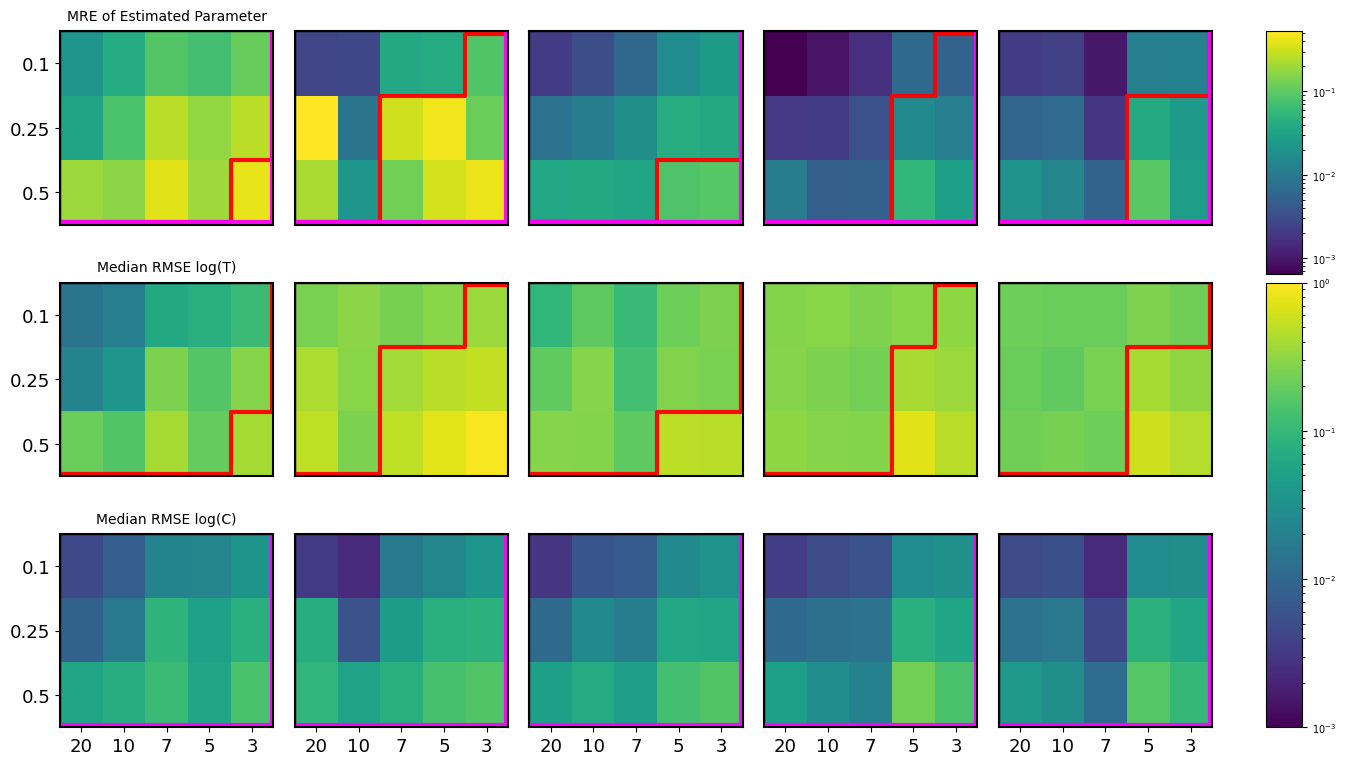

In [47]:
# Cell 3: Plotting for all_params, CR only ("toprightGemini")
# Ensure Cell 1C (with plot_figure_cell3) and Cell 2 are executed before this.
use_log_scale_cell3 = True 
print(f"\n--- Plotting Cell 3 Figure (3x5, 1 Cbar per Row) ---")

plot_figure_cell3( 
    all_params_list=all_params,
    aggregated_data_map=aggregated_data_storage,
    row_bounds_dict=cmap_bounds_CR_only, 
    log_scale=use_log_scale_cell3,
    save_path="poster_images/toprightGemini/combined_figure_all_params_CR.png"
)


--- Plotting Cell 4 Figure (2x3 Total, 1 Cbar per Column) ---
Saved Cell4 to poster_images/middlerightGemini/combined_figure_NR_params_2x3.png


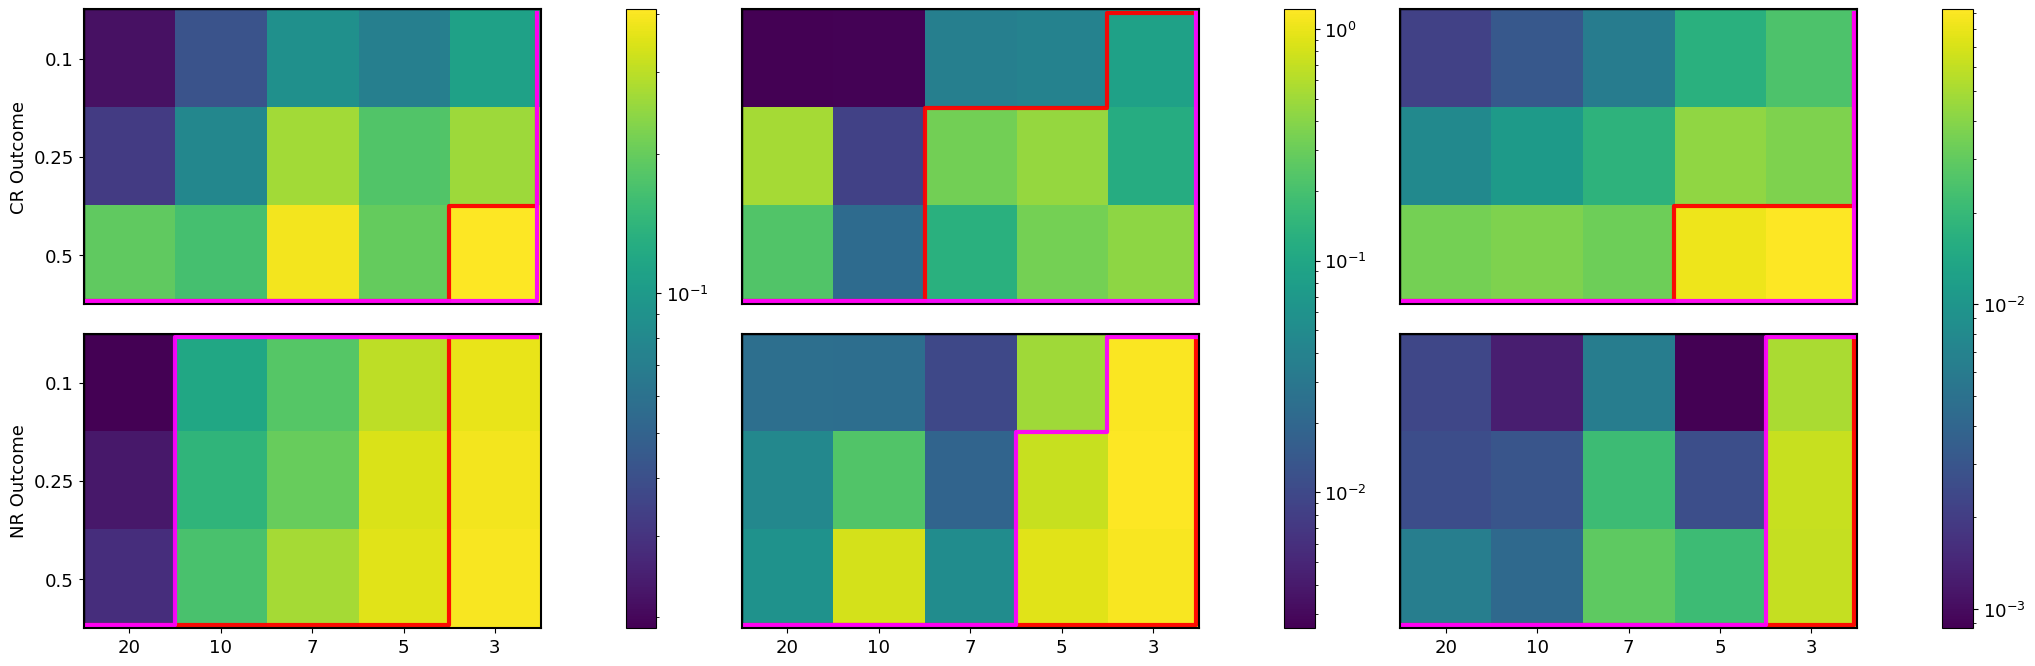

In [48]:
# Cell 4: Plotting for params_with_NRs ("middlerightGemini")
# Ensure Cell 1C (with plot_figure_cell4) and Cell 2 are executed before this.
use_log_scale_cell4 = True 
print(f"\n--- Plotting Cell 4 Figure (2x3 Total, 1 Cbar per Column) ---")

plot_figure_cell4( 
    params_for_cols_list=params_with_NRs, 
    aggregated_data_map=aggregated_data_storage,
    metric_to_plot_template="param_relative_err_{outcome}", 
    log_scale=use_log_scale_cell4,
    save_path="poster_images/middlerightGemini/combined_figure_NR_params_2x3.png"
)